In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    BatchNormalization, Conv2D, MaxPooling2D, Activation, Flatten, Dropout, Dense)
import os
import cv2
import shutil
from PIL import Image
import numpy as np
from matplotlib import pyplot as plt
import glob

In [ ]:
 from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
shutil.copytree('/content/drive/MyDrive/HRF/images','/content/drive/MyDrive/Train')

'/content/drive/MyDrive/Train'

In [ ]:
shutil.copytree('/content/drive/MyDrive/HRF/manual1','/content/drive/MyDrive/Test')

'/content/drive/MyDrive/Test'

In [ ]:
shutil.copytree('/content/drive/MyDrive/HRF/mask','/content/drive/MyDrive/Validate')

'/content/drive/MyDrive/Validate'

In [ ]:
SIZE=256 #Resize images (height  = X, width = Y)


#Capture training image info as a list
train_images = []
path = "/content/drive/MyDrive/Train/*.*"

for file in sorted(glob.glob(path)):
        #img = cv2.imread(file, 0)
        img = cv2.imread(file, cv2.IMREAD_COLOR)
        img = cv2.resize(img, (SIZE, SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        #img = img/255.
        #img= img.astype(np.float32)
        train_images.append(img)

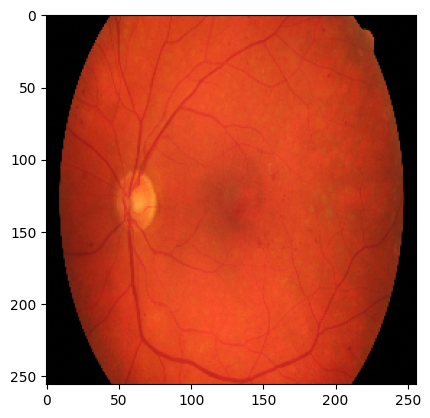

In [ ]:
plt.imshow(train_images[0])

In [ ]:
len(train_images)

45

In [ ]:
print(np.max(train_images))

255


In [ ]:
import glob
SIZE=256 #Resize images (height  = X, width = Y)
import cv2

#Capture training image info as a list
train_masks = []
path = "/content/drive/MyDrive/Test/*.*"

for file in sorted(glob.glob(path)):
        img = cv2.imread(file,cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img,(SIZE, SIZE))
        img=np.array(img)
        for i in range (0,SIZE):
          for j in range (0,SIZE):
            #print(img[i,j])
            if img[i,j]>125:
              img[i,j]=1
            else:
              img[i,j]=0

        train_masks.append(img)
          #print(img[i,j])

        #if img
        #img = img.astype(np.int32)

        #img = img/255.
         #img = cv2.imread(file,cv2.IMREAD_COLOR)
        #img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)



In [ ]:
train_images= np.array(train_images)

In [ ]:
'''train_masks[3][151,150]

list(train_masks[3])'''

'train_masks[3][151,150]\n\nlist(train_masks[3])'

1
0


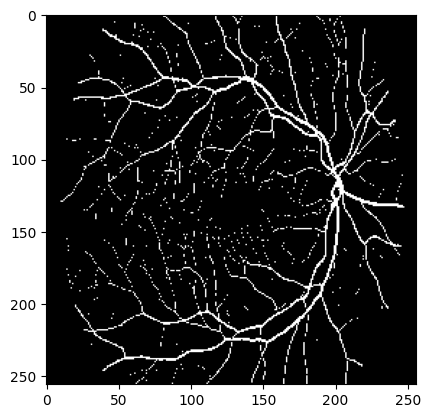

In [ ]:
plt.imshow(train_masks[1]*255,cmap='gray')

print(np.max(train_masks[1]))
print(np.min(train_masks[1]))

In [ ]:
train_masks= np.array(train_masks)
print(train_masks.shape)

(45, 256, 256)


In [ ]:
"""for i in range(0,45):

  plt.figure(i)

  plt.subplot(121)
  plt.imshow(train_images[i])
  plt.subplot(122)
  plt.imshow(train_masks[i])
  plt.show( print(i))"""


'for i in range(0,45):\n  \n  plt.figure(i)\n\n  plt.subplot(121)\n  plt.imshow(train_images[i])\n  plt.subplot(122)\n  plt.imshow(train_masks[i])\n  plt.show( print(i))'

In [ ]:
train_masks=np.expand_dims(train_masks,axis=-1)
#train_masks= np.squeeze(train_masks)
train_masks.shape

(45, 256, 256, 1)

In [ ]:
train_masks
print(np.max(train_masks))

1


In [ ]:
IMG_HEIGHT = 512
IMG_WIDTH =512
IMG_CHANNELS =3

In [ ]:
#simple 1*1 inception convolution network
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda, AveragePooling2D

def inception_module(x, filters):
    # 1x1 convolution
    conv1x1 = Conv2D(filters[0], (1, 1), activation='relu', padding='same', kernel_initializer='he_normal')(x)

    # 3x3 convolution
    conv3x3 = Conv2D(filters[1], (1, 1), activation='relu', padding='same', kernel_initializer='he_normal')(x)
    conv3x3 = Conv2D(filters[2], (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(conv3x3)

    # 5x5 convolution
    conv5x5 = Conv2D(filters[3], (1, 1), activation='relu', padding='same', kernel_initializer='he_normal')(x)
    conv5x5 = Conv2D(filters[4], (5, 5), activation='relu', padding='same', kernel_initializer='he_normal')(conv5x5)

    # Max pooling
    pool = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    pool = Conv2D(filters[5], (1, 1), activation='relu', padding='same', kernel_initializer='he_normal')(pool)

    # Concatenate all branches
    output = concatenate([conv1x1, conv3x3, conv5x5, pool], axis=-1)
    return output

def unet_with_inception(input_size=(256, 256, 3)):
    inputs = Input(input_size)

    # Contraction path with Inception modules
    # Block 1
    c1 = inception_module(inputs, [16, 16, 16, 16, 16, 16])
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    # Block 2
    c2 = inception_module(p1, [32, 32, 32, 32, 32, 32])
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    # Block 3
    c3 = inception_module(p2, [64, 64, 64, 64, 64, 64])
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    # Block 4
    c4 = inception_module(p3, [128, 128, 128, 128, 128, 128])
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = MaxPooling2D((2, 2))(c4)

    # Bottom
    c5 = inception_module(p4, [256, 256, 256, 256, 256, 256])
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

    # Expansive path (keeping original structure for decoder)
    u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = inception_module(u6, [128, 128, 128, 128, 128, 128])
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)

    u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = inception_module(u7, [64, 64, 64, 64, 64, 64])
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)

    u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = inception_module(u8, [32, 32, 32, 32, 32, 32])
    c8 = Dropout(0.1)(c8)
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)

    u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = inception_module(u9, [16, 16, 16, 16, 16, 16])
    c9 = Dropout(0.1)(c9)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

# Create model
model = unet_with_inception(input_size=(SIZE, SIZE, IMG_CHANNELS))
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 256, 256,  │         64 │ input_layer_2[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 256, 256,  │         64 │ input_layer_2[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 256, 256,  │          0 │ input_layer_2[0]… │
│ (MaxPooling2D)      │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 256, 256,  │         64 │ input_layer_2[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 256, 256,  │      2,320 │ conv2d_39[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 256, 256,  │      6,416 │ conv2d_41[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 256, 256,  │         64 │ max_pooling2d_8[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 256, 256,  │          0 │ conv2d_38[0][0],  │
│ (Concatenate)       │ 64)               │            │ conv2d_40[0][0],  │
│                     │                   │            │ conv2d_42[0][0],  │
│                     │                   │            │ conv2d_43[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 256, 256,  │          0 │ concatenate_8[0]… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 256, 256,  │      9,232 │ dropout_18[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 128, 128,  │          0 │ conv2d_44[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 128, 128,  │        544 │ max_pooling2d_9[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_48 (Conv2D)  │ (None, 128, 128,  │        544 │ max_pooling2d_9[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 128, 128,  │          0 │ max_pooling2d_9[… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 128, 128,  │        544 │ max_pooling2d_9[… │
│                     │ 32)               │            │                 

 Total params: 8,161,761 (31.13 MB)

 Trainable params: 8,161,761 (31.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(train_images,train_masks,test_size =0.1,random_state = 42)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
            history = model.fit(X_train, y_train,
                    batch_size =4,
                    verbose=1,
                    epochs=10,
                    validation_data=(X_test,y_test))

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_82']
Received: inputs=Tensor(shape=(4, 256, 256, 3))
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_82']
Received: inputs=Tensor(shape=(4, 256, 256, 3))
  warnings.warn(msg)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.8397 - loss: 10.8513 

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_82']
Received: inputs=Tensor(shape=(None, 256, 256, 3))
  warnings.warn(msg)


10/10 ━━━━━━━━━━━━━━━━━━━━ 196s 16s/step - accuracy: 0.8415 - loss: 10.4433 - val_accuracy: 0.9164 - val_loss: 0.4850
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 151s 15s/step - accuracy: 0.7871 - loss: 1.0521 - val_accuracy: 0.8979 - val_loss: 0.5071
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 206s 16s/step - accuracy: 0.8840 - loss: 0.4688 - val_accuracy: 0.9199 - val_loss: 0.4535
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 203s 16s/step - accuracy: 0.9213 - loss: 0.3376 - val_accuracy: 0.9199 - val_loss: 0.4718
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 200s 15s/step - accuracy: 0.9239 - loss: 0.3052 - val_accuracy: 0.9200 - val_loss: 0.3887
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 153s 15s/step - accuracy: 0.9228 - loss: 0.2919 - val_accuracy: 0.9200 - val_loss: 0.3901
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 204s 16s/step - accuracy: 0.9225 - loss: 0.2831 - val_accuracy: 0.9200 - val_loss: 0.3834
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 201s 15s/step - accuracy: 0.9245 - loss: 0.2738 - val_accuracy: 0.9200 - val

In [ ]:
model.save('Unetseg.hdf5')

In [ ]:
_, acc = model.evaluate(X_test, y_test)
print("Accuracy = ", (acc * 100.0), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.9200 - loss: 0.3057
Accuracy =  91.99798703193665 %


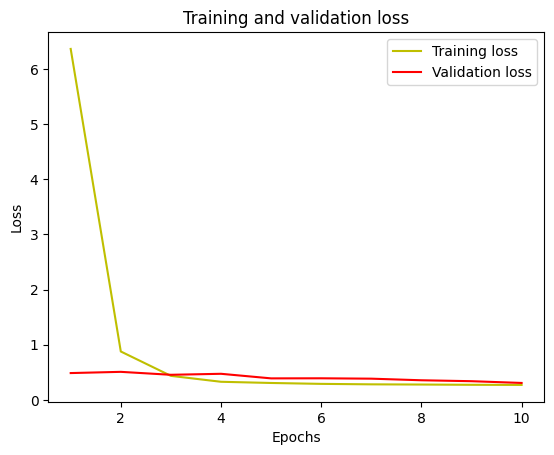

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
(256, 256)
(1, 256, 1)


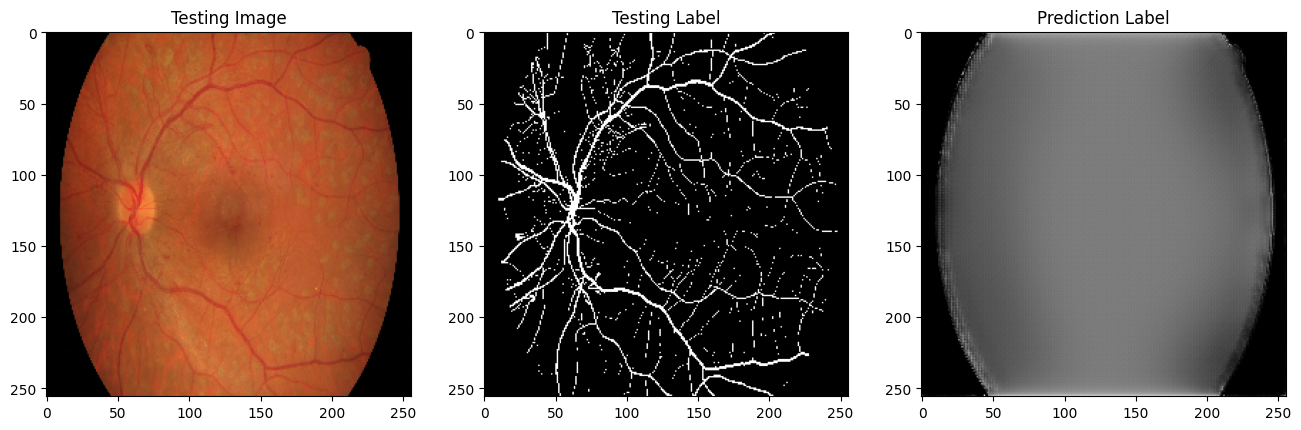

In [ ]:
from keras.models import load_model
import random
#model = load_model('Unetseg.hdf5')

test_img_number = random.randint(0, len(X_test)-1)
test_img = X_test[test_img_number]
ground_truth=y_test[test_img_number]
#test_img_norm=test_img[:,:,:]
test_img_input=np.expand_dims(test_img, -1)
test_img_input=np.expand_dims(test_img_input, 0)
prediction = (model.predict(test_img_input))

pred=np.asarray(prediction)
grd =np.asarray(ground_truth)
pred.shape
plt.figure(figsize=(16, 8))
plt.subplot(131)
plt.title('Testing Image')
plt.imshow(test_img, cmap='gray')
plt.subplot(132)
plt.title('Testing Label')
plt.imshow(grd[:,:,0]*255, cmap='gray')
print(grd[:,:,0].shape)
plt.subplot(133)
plt.title('Prediction Label')
#plt.imshow(pred, cmap='gray')
print(pred[:,:,0].shape)
plt.imshow((pred[0][:,:,0])*255, cmap='gray')
plt.show()